## Part 1: Import the Required Libraries

In this section, we import all the necessary libraries for data handling, text processing, and visualization.

In [71]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## 1. Load Dataset

First, we need to download the dataset from Kaggle and load it into a pandas DataFrame.

In [72]:
# Install opendatasets for Kaggle data downloading
%pip install opendatasets --quiet

import opendatasets as od
import pandas as pd

# Kaggle dataset URL
dataset_url = 'https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment'

# Download the dataset (you may be prompted for Kaggle username and API key)
od.download(dataset_url)


Skipping, found downloaded files in "./twitter-airline-sentiment" (use force=True to force download)


In [73]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('twitter-airline-sentiment/Tweets.csv')

# Display the first 5 rows of the DataFrame
print('Dataset loaded successfully. Here are the first 5 rows:')
display(df.head())

Dataset loaded successfully. Here are the first 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## Part 2: Data Exploration

In this section, we examine the structure, statistics, and types of data within our dataset to answer the preliminary analysis questions.

In [74]:
# 1. Display first and last 5 rows
print("First 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())

# 2. Number of rows and columns
print(f"\nDataset Shape: {df.shape} (Rows, Columns)")

# 3. Column names and datatypes
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDatatypes:")
print(df.dtypes)

# 4. General Information
print("\nGeneral Information:")
df.info()

# 5. Descriptive Statistics
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

First 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)



Last 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)
14639,569587140490866689,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know h...,NaN,2015-02-22 11:58:51 -0800,"dallas, TX",NaN



Dataset Shape: (14640, 15) (Rows, Columns)

Column Names:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Datatypes:
tweet_id                          int64
airline_sentiment                object
airline_sentiment_confidence    float64
negativereason                   object
negativereason_confidence       float64
airline                          object
airline_sentiment_gold           object
name                             object
negativereason_gold              object
retweet_count                     int64
text                             object
tweet_coord                      object
tweet_created                    object
tweet_location                   object
user_timezone                    object
dtype: object

General Information:
<class 'pandas.core.

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
count,1.464000e+04,14640,14640.000000,9178,10522.000000,14640,40,14640,32,14640.000000,14640,1019,14640,9907,9820
unique,NaN,3,NaN,10,NaN,6,3,7701,13,NaN,14427,832,14247,3081,85
top,NaN,negative,NaN,Customer Service Issue,NaN,United,negative,JetBlueNews,Customer Service Issue,NaN,@united thanks,"[0.0, 0.0]",2015-02-24 09:54:34 -0800,"Boston, MA",Eastern Time (US & Canada)
freq,NaN,9178,NaN,2910,NaN,3822,32,63,12,NaN,6,164,5,157,3744
mean,5.692184e+17,NaN,0.900169,NaN,0.638298,NaN,NaN,NaN,NaN,0.082650,NaN,NaN,NaN,NaN,NaN
std,7.791112e+14,NaN,0.162830,NaN,0.330440,NaN,NaN,NaN,NaN,0.745778,NaN,NaN,NaN,NaN,NaN
min,5.675883e+17,NaN,0.335000,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,5.685592e+17,NaN,0.692300,NaN,0.360600,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
50%,5.694779e+17,NaN,1.000000,NaN,0.670600,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
75%,5.698905e+17,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN


### Analysis and Answers:

1.  **How many reviews in dataset?**: There are 14,640 reviews (based on the row count).
2.  **Which column contains the reviews or user comments?**: The `text` column.
3.  **Which column contains the sentiment label?**: The `airline_sentiment` column.
4.  **Are there any unnecessary columns?**: Yes, columns like `tweet_id`, `airline_sentiment_gold`, `name`, `negativereason_gold`, `tweet_coord`, `tweet_created`, `tweet_location`, and `user_timezone` may not be necessary for basic text preprocessing and sentiment analysis.
5.  **Is the review column stored as text?**: Yes, the `text` column has an `object` dtype (which pandas uses for strings).
6.  **Are there any clear data problems?**:
    *   There are significant missing values in `negativereason`, `airline_sentiment_gold`, `negativereason_gold`, `tweet_coord`, `tweet_location`, and `user_timezone`.
    *   We should check for duplicate rows in the `text` column specifically.

## Part 3: In-depth Review and Sentiment Analysis

In this section, we analyze the text length, word counts, and sentiment patterns, and visualize the findings.

In [75]:
# Create length (character count) and word_count columns
df['review_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# 1 & 2. Shortest and Longest reviews (by character length)
shortest_row = df.loc[df['review_length'].idxmin()]
longest_row = df.loc[df['review_length'].idxmax()]

print(f"1. Shortest review: '{shortest_row['text']}' (Length: {shortest_row['review_length']})")
print(f"2. Longest review: '{longest_row['text']}' (Length: {longest_row['review_length']})")

# 3 & 5. Average length and Average number of words
print(f"\n3. Average review length (chars): {df['review_length'].mean():.2f}")
print(f"5. Average number of words: {df['word_count'].mean():.2f}")

# 4. The number of words in each review
print("\n4. The number of words in each review (first 10 rows):")
display(df[['text', 'word_count']].head(10))

# 6. The five longest reviews (by word count)
print("\n6. The five longest reviews:")
display(df.nlargest(5, 'word_count')[['text', 'word_count', 'review_length']])

# 7. Sentiment distribution
print(f"\n7. Sentiment Distribution:\n{df['airline_sentiment'].value_counts()}")

# 8. Number of reviews for each airline
print(f"\n8. Number of reviews for each airline:\n{df['airline'].value_counts()}")

# 9. Sentiment distribution for each airline
print("\n9. Sentiment distribution for each airline:")
airline_sentiment_dist = pd.crosstab(df['airline'], df['airline_sentiment'])
display(airline_sentiment_dist)

# 10. Most common negative reasons
print(f"\n10. Most common negative reasons:\n{df['negativereason'].value_counts()}")

# 11. Compare average review length for Positive, Negative, and Neutral
print("\n11. Average review length (chars) by sentiment:")
avg_len_by_sent = df.groupby('airline_sentiment')['review_length'].mean()
print(avg_len_by_sent)


1. Shortest review: '@united done' (Length: 12)
2. Longest review: '@USAirways Eyyyy! Cancelled Flightlations, Flight Booking Problemss, reFlight Booking Problemss, but y'all got me on the same flight out tonight (not tomorrow) &amp; the FC upgrade. Thx!' (Length: 186)

3. Average review length (chars): 103.82
5. Average number of words: 17.65

4. The number of words in each review (first 10 rows):


,text,word_count
0,@VirginAmerica What @dhepburn said.,4
1,@VirginAmerica plus you've added commercials t...,9
2,@VirginAmerica I didn't today... Must mean I n...,12
3,@VirginAmerica it's really aggressive to blast...,17
4,@VirginAmerica and it's a really big bad thing...,10
5,@VirginAmerica seriously would pay $30 a fligh...,23
6,"@VirginAmerica yes, nearly every time I fly VX...",15
7,@VirginAmerica Really missed a prime opportuni...,13
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",8
9,"@VirginAmerica it was amazing, and arrived an ...",14



6. The five longest reviews:


,text,word_count,review_length
8062,@JetBlue I ❤️ Jetblue but i was on flt 277 fro...,36,156
9435,"@USAirways 4 segments, 4/4 delayed. Gnv &gt; C...",33,151
537,@united I sure did. I had to drive a total o...,32,140
1189,@united Ha… you rebooked me in to an 11 hr lay...,32,151
2649,@united I was on hold for over 20 minutes and ...,32,139



7. Sentiment Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

8. Number of reviews for each airline:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

9. Sentiment distribution for each airline:


airline_sentiment,negative,neutral,positive
airline,,,
American,1960,463,336
Delta,955,723,544
Southwest,1186,664,570
US Airways,2263,381,269
United,2633,697,492
Virgin America,181,171,152



10. Most common negative reasons:
negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64

11. Average review length (chars) by sentiment:
airline_sentiment
negative    113.947919
neutral      87.359471
positive     86.082945
Name: review_length, dtype: float64


/tmp/ipykernel_1029/4225768632.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline_sentiment', palette='viridis')
/tmp/ipykernel_1029/4225768632.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline', order=df['airline'].value_counts().index, palette='magma')
/tmp/ipykernel_1029/4225768632.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='negativereason', order=df['negativereason'].value_counts().index, palette='rocket')


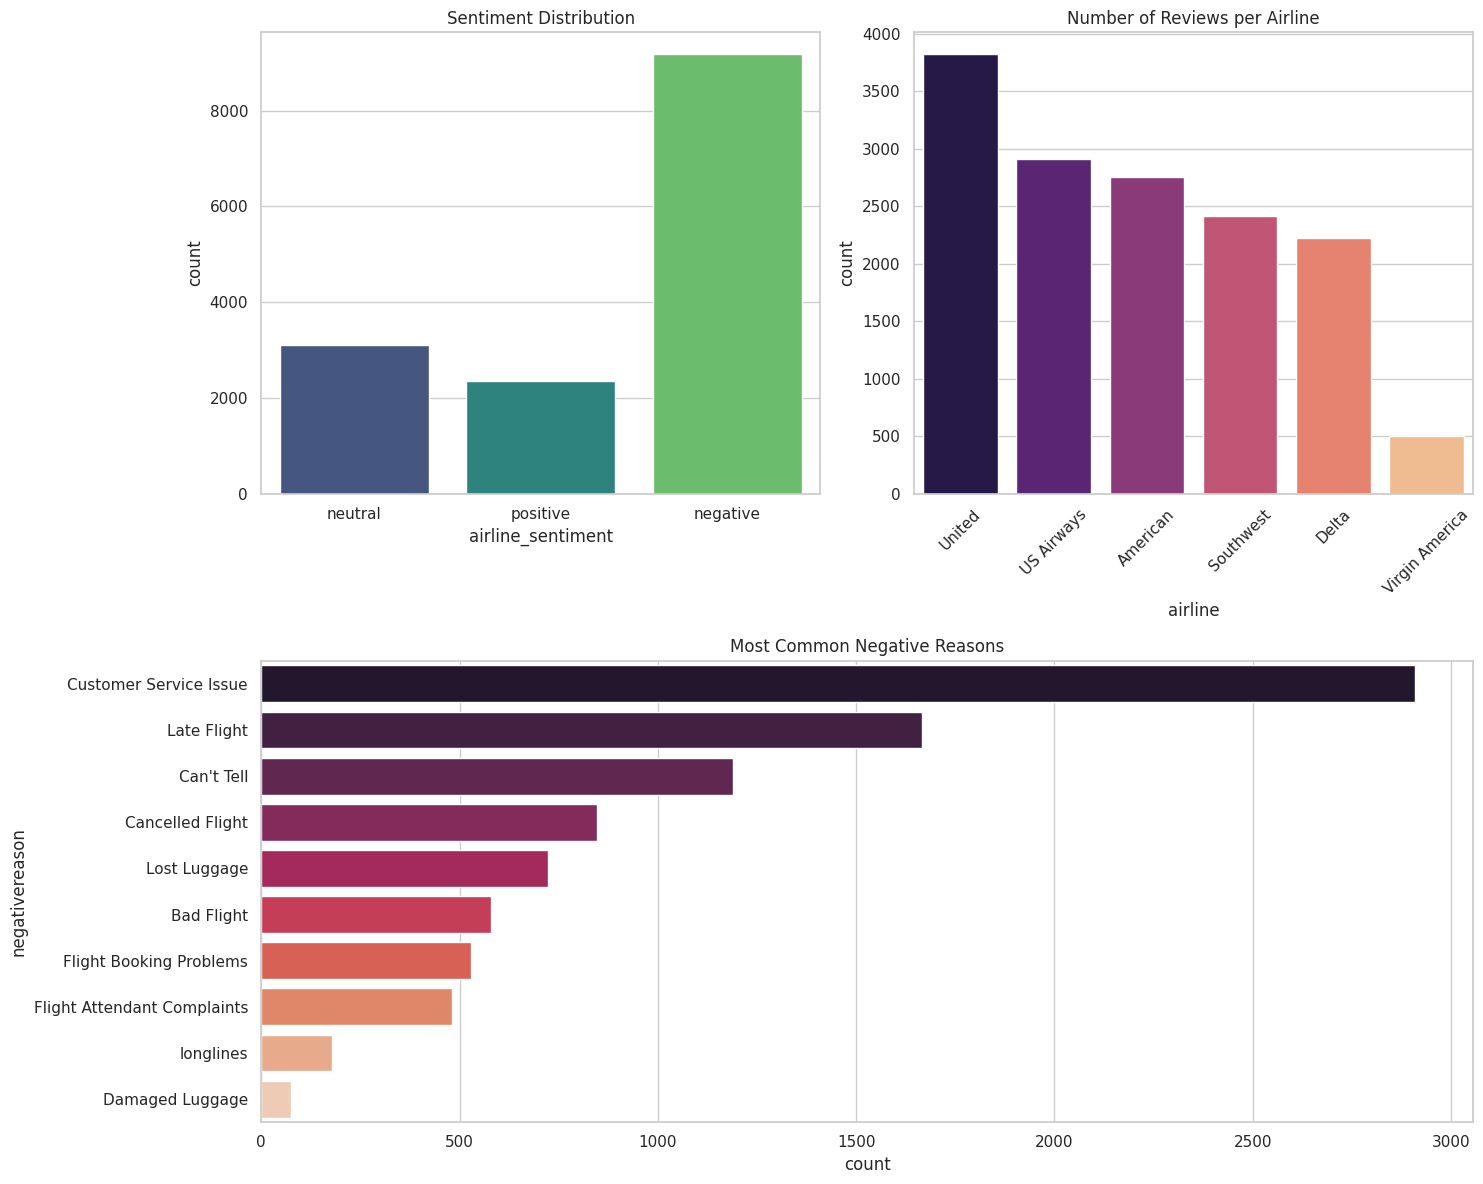

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(15, 12))

# 1. Sentiment distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='airline_sentiment', palette='viridis')
plt.title('Sentiment Distribution')

# 2. Number of reviews per airline
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='airline', order=df['airline'].value_counts().index, palette='magma')
plt.xticks(rotation=45)
plt.title('Number of Reviews per Airline')

# 3. Most common negative reasons
plt.subplot(2, 1, 2)
sns.countplot(data=df, y='negativereason', order=df['negativereason'].value_counts().index, palette='rocket')
plt.title('Most Common Negative Reasons')

plt.tight_layout()
plt.show()

### Sentiment Distribution by Airline

We will visualize how sentiments (positive, neutral, negative) are distributed across the different airlines in our dataset.

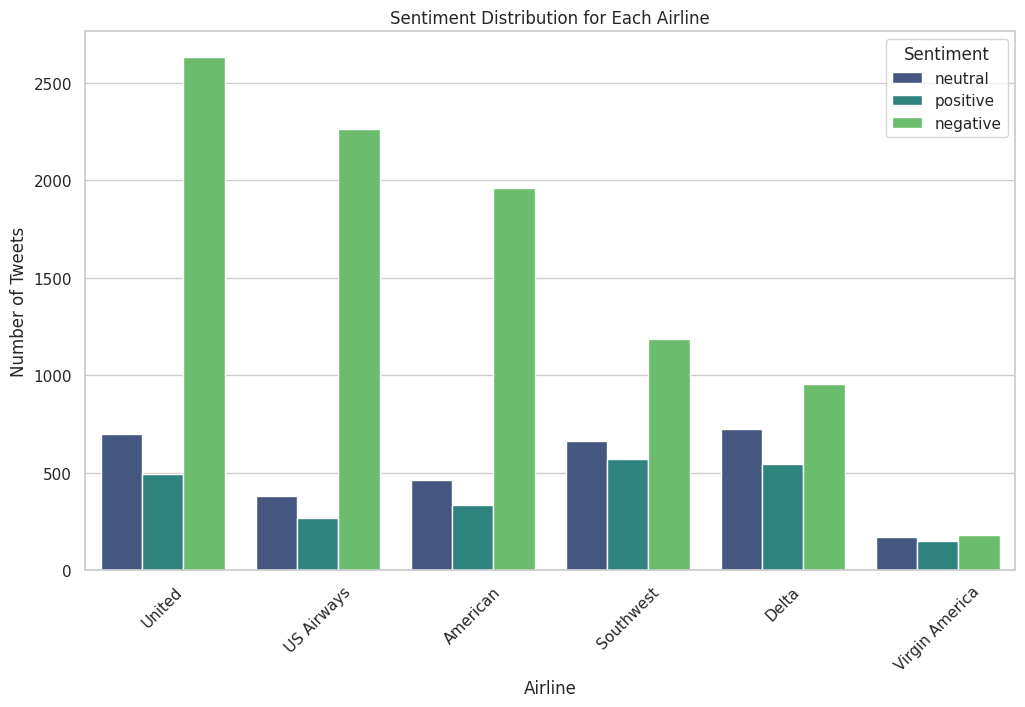

Percentage Sentiment Distribution per Airline:


airline_sentiment,negative,neutral,positive
airline,,,
American,71.04,16.78,12.18
Delta,42.98,32.54,24.48
Southwest,49.01,27.44,23.55
US Airways,77.69,13.08,9.23
United,68.89,18.24,12.87
Virgin America,35.91,33.93,30.16


In [77]:
plt.figure(figsize=(12, 7))

# Create a countplot with 'airline' on the x-axis and 'airline_sentiment' as the hue
sns.countplot(data=df, x='airline', hue='airline_sentiment', palette='viridis', order=df['airline'].value_counts().index)

plt.title('Sentiment Distribution for Each Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.show()

# Also show the percentage-based distribution for a better comparison
print("Percentage Sentiment Distribution per Airline:")
airline_sentiment_pct = pd.crosstab(df['airline'], df['airline_sentiment'], normalize='index') * 100
display(airline_sentiment_pct.round(2))

## Part 4: Handling Missing Values

We will analyze the extent of missing data and apply strategies such as dropping redundant/empty columns and filling missing entries where appropriate.

In [78]:
# 1. Count missing values
null_counts = df.isnull().sum()

# 2. Calculate percentage of missing values
null_percentages = (df.isnull().sum() / len(df)) * 100

# Create a summary table
missing_data = pd.DataFrame({'Total Nulls': null_counts, 'Percentage (%)': null_percentages})
display(missing_data.sort_values(by='Total Nulls', ascending=False))

# 3. Check for rows with missing review text
missing_reviews = df[df['text'].isnull()]
print(f"\nNumber of rows with missing review text: {len(missing_reviews)}")
if len(missing_reviews) > 0:
    display(missing_reviews)

,Total Nulls,Percentage (%)
negativereason_gold,14608,99.781421
airline_sentiment_gold,14600,99.726776
tweet_coord,13621,93.039617
negativereason,5462,37.308743
user_timezone,4820,32.923497
tweet_location,4733,32.329235
negativereason_confidence,4118,28.128415
tweet_id,0,0.000000
airline_sentiment,0,0.000000
name,0,0.000000



Number of rows with missing review text: 0


In [79]:

# 1. Drop columns with excessive missing values or irrelevant metadata
cols_to_drop = [
    'tweet_id', 'airline_sentiment_gold', 'negativereason_gold',
    'tweet_coord', 'tweet_location', 'tweet_created', 'name'
]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 2. Handle 'negativereason'
# It's expected to be null for positive/neutral tweets. We can fill it with 'Not Applicable'
df['negativereason'] = df['negativereason'].fillna('N/A')

print("\nMissing values after handling:")
print(df.isnull().sum())

# Display remaining columns
print("\nRemaining columns:")
print(df.columns.tolist())


Missing values after handling:
airline_sentiment                  0
airline_sentiment_confidence       0
negativereason                     0
negativereason_confidence       4118
airline                            0
retweet_count                      0
text                               0
user_timezone                   4820
review_length                      0
word_count                         0
dtype: int64

Remaining columns:
['airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'retweet_count', 'text', 'user_timezone', 'review_length', 'word_count']


### Missing Value Detailed Analysis

We will calculate the count and percentage of missing values for each column and check for any rows where the actual review text is missing.

### Handling Missing Values Decision

**Decision:** We will remove any rows that have null values in the `text` column because sentiment analysis cannot be performed without the source text. For other columns like `negativereason_confidence`, we may keep the rows but acknowledge the missing metadata.

In [80]:
# Remove rows where 'text' is null
df.dropna(subset=['text'], inplace=True)

# Checkpoint: verify no nulls in text column
print("Checkpoint - Nulls in 'text' column:", df['text'].isnull().sum())

Checkpoint - Nulls in 'text' column: 0


## Part 5: Handling Duplicate Data

To ensure our sentiment analysis is not biased by repeated tweets, we will identify and remove duplicates in the `text` column.

In [81]:
# 1. Count the duplicated reviews in the 'text' column
duplicate_mask = df['text'].duplicated(keep=False)
duplicate_count = df['text'].duplicated().sum()

print(f"Total number of duplicate reviews: {duplicate_count}")

# 2. Display rows of duplicated review text
if duplicate_count > 0:
    print("\nRows with duplicated review text (displaying first 10 occurrences):")
    display(df[duplicate_mask].sort_values(by='text').head(10))

# 3. Store initial count for comparison
initial_rows = len(df)

# 4. Remove the duplicated rows
df.drop_duplicates(subset='text', keep='first', inplace=True)

# 5. Display the number of rows before and after removing duplicates
final_rows = len(df)
print(f"\nNumber of rows before removing duplicates: {initial_rows}")
print(f"Number of rows after removing duplicates: {final_rows}")
print(f"Total rows removed: {initial_rows - final_rows}")

Total number of duplicate reviews: 213

Rows with duplicated review text (displaying first 10 occurrences):


,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,retweet_count,text,user_timezone,review_length,word_count
12067,negative,1.0000,Customer Service Issue,1.0000,American,0,.@AmericanAir can you connect me to a person w...,Eastern Time (US & Canada),135,25
11906,negative,0.6703,Customer Service Issue,0.6703,American,0,.@AmericanAir can you connect me to a person w...,Eastern Time (US & Canada),135,25
11902,neutral,1.0000,N/A,NaN,American,0,.@AmericanAir just disappointed with the Fligh...,Mountain Time (US & Canada),155,25
12063,neutral,1.0000,N/A,NaN,American,0,.@AmericanAir just disappointed with the Fligh...,Mountain Time (US & Canada),155,25
11946,negative,1.0000,Lost Luggage,0.6593,American,0,@AmericanAir\n Your response could have made a...,NaN,137,22
12107,negative,1.0000,Lost Luggage,1.0000,American,0,@AmericanAir\n Your response could have made a...,NaN,137,22
12128,negative,1.0000,Can't Tell,0.6590,American,0,@AmericanAir \nIt's not what happens to us tha...,NaN,113,19
11967,negative,1.0000,Customer Service Issue,0.6523,American,0,@AmericanAir \nIt's not what happens to us tha...,NaN,113,19
13995,negative,1.0000,Customer Service Issue,1.0000,American,0,@AmericanAir 800 number will not even let you...,NaN,114,19
12029,negative,1.0000,Customer Service Issue,0.9620,American,0,@AmericanAir 800 number will not even let you...,NaN,114,19



Number of rows before removing duplicates: 14640
Number of rows after removing duplicates: 14427
Total rows removed: 213


## Part 6: Text Cleaning

In this section, we will prepare the text data for analysis by creating a copy of the original reviews and applying various cleaning steps to a new `clean_review` column.

In [82]:
# Keep the original review in a column called 'original_review'
df['original_review'] = df['text']

# Create another column called 'clean_review' to apply cleaning steps
df['clean_review'] = df['original_review']

print("Original and clean review columns created successfully.")
print("First 5 original reviews:")
display(df[['original_review', 'clean_review']].head())

Original and clean review columns created successfully.
First 5 original reviews:


,original_review,clean_review
0,@VirginAmerica What @dhepburn said.,@VirginAmerica What @dhepburn said.
1,@VirginAmerica plus you've added commercials t...,@VirginAmerica plus you've added commercials t...
2,@VirginAmerica I didn't today... Must mean I n...,@VirginAmerica I didn't today... Must mean I n...
3,@VirginAmerica it's really aggressive to blast...,@VirginAmerica it's really aggressive to blast...
4,@VirginAmerica and it's a really big bad thing...,@VirginAmerica and it's a really big bad thing...


### Step 1: Convert Text to Lowercase

Converting all characters to lowercase ensures that the model treats words like 'Flight' and 'flight' identically.

In [83]:
# Step 1: Lowercase the text
df['clean_review'] = df['clean_review'].str.lower()

# Checkpoint: Verify no uppercase letters remain
uppercase_count = df['clean_review'].str.contains(r'[A-Z]', regex=True).sum()
print(f"Number of rows containing uppercase English letters: {uppercase_count}")

# Display the head to see lowercaseing
print("Inspecting lowercase conversion (original vs clean):")
display(df[['original_review', 'clean_review']].head())

Number of rows containing uppercase English letters: 0
Inspecting lowercase conversion (original vs clean):


,original_review,clean_review
0,@VirginAmerica What @dhepburn said.,@virginamerica what @dhepburn said.
1,@VirginAmerica plus you've added commercials t...,@virginamerica plus you've added commercials t...
2,@VirginAmerica I didn't today... Must mean I n...,@virginamerica i didn't today... must mean i n...
3,@VirginAmerica it's really aggressive to blast...,@virginamerica it's really aggressive to blast...
4,@VirginAmerica and it's a really big bad thing...,@virginamerica and it's a really big bad thing...


### Step 2: Remove URLs

URLs like `https://example.com` or `www.website.com` are typically noise in sentiment analysis and should be removed.

In [84]:
# Step 2: Remove URLs using a more robust regex
# This pattern catches http, https, and standalone www. links
df['clean_review'] = df['clean_review'].str.replace(r'http\S+|https\S+|www\.\S+', '', regex=True)

# Checkpoint: Verify no 'http' or 'www' remains
http_count = df['clean_review'].str.contains('http').sum()
www_count = df['clean_review'].str.contains('www').sum()

print(f"Rows containing 'http': {http_count}")
print(f"Rows containing 'www': {www_count}")

# Display a few rows to inspect
display(df[['original_review', 'clean_review']].head())

Rows containing 'http': 0
Rows containing 'www': 5


,original_review,clean_review
0,@VirginAmerica What @dhepburn said.,@virginamerica what @dhepburn said.
1,@VirginAmerica plus you've added commercials t...,@virginamerica plus you've added commercials t...
2,@VirginAmerica I didn't today... Must mean I n...,@virginamerica i didn't today... must mean i n...
3,@VirginAmerica it's really aggressive to blast...,@virginamerica it's really aggressive to blast...
4,@VirginAmerica and it's a really big bad thing...,@virginamerica and it's a really big bad thing...


Here remains one of the row has a **"www"** , it is a subset of **mentioning name** , not a url , so will handle it later.


### Step 3: Remove HTML Tags

HTML tags like `<br>`, `<b>`, or `<div>` are often artifacts of web scraping or data encoding and don't contribute to sentiment. We will remove them to keep the text clean.

In [85]:
from bs4 import BeautifulSoup

# Function to remove HTML tags
def remove_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

# Apply the function to the clean_review column
df['clean_review'] = df['clean_review'].apply(remove_html)

# Checkpoint: Verify no '<' or '>' symbols remain (common indicators of HTML tags)
html_tag_indicators = df['clean_review'].str.contains('<|>').sum()
print(f"Number of rows containing HTML tag indicators (< or >): {html_tag_indicators}")

# Display a sample to verify
display(df[['original_review', 'clean_review']].head())

Number of rows containing HTML tag indicators (< or >): 110


,original_review,clean_review
0,@VirginAmerica What @dhepburn said.,@virginamerica what @dhepburn said.
1,@VirginAmerica plus you've added commercials t...,@virginamerica plus you've added commercials t...
2,@VirginAmerica I didn't today... Must mean I n...,@virginamerica i didn't today... must mean i n...
3,@VirginAmerica it's really aggressive to blast...,@virginamerica it's really aggressive to blast...
4,@VirginAmerica and it's a really big bad thing...,@virginamerica and it's a really big bad thing...


### Step 4: Remove Email Addresses

Email addresses are personal identifiers and don't provide useful context for general sentiment analysis. We will remove them using regular expressions.

In [86]:
# Step 4: Remove Email Addresses
# Refined regex: ensures there is at least one non-space character before the '@'
# and that it does not start with '@' (which would be a mention).
email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
df['clean_review'] = df['clean_review'].str.replace(email_pattern, '', regex=True)

# Checkpoint: Verify no actual email patterns remain
# A simple '@' count now represents mentions, so we look for the dot-com/org/net suffix to identify remaining emails
emails_remaining = df['clean_review'].str.contains(r'\S+@\S+\.\S+').sum()
print(f"Number of rows potentially containing email addresses: {emails_remaining}")

# Display a sample to verify mentions are preserved while emails are gone
display(df[['original_review', 'clean_review']].head())

Number of rows potentially containing email addresses: 0


,original_review,clean_review
0,@VirginAmerica What @dhepburn said.,@virginamerica what @dhepburn said.
1,@VirginAmerica plus you've added commercials t...,@virginamerica plus you've added commercials t...
2,@VirginAmerica I didn't today... Must mean I n...,@virginamerica i didn't today... must mean i n...
3,@VirginAmerica it's really aggressive to blast...,@virginamerica it's really aggressive to blast...
4,@VirginAmerica and it's a really big bad thing...,@virginamerica and it's a really big bad thing...


### Step 5: Handle Mentions and Hashtags

- **Mentions:** We remove the entire `@username` string as it is noise.
- **Hashtags:** We remove only the `#` character and keep the word, as hashtags often contain important sentiment keywords.

In [87]:
# 1. Remove mentions (@username) and all remaining '@' symbols
# First, remove the full mention pattern
df['clean_review'] = df['clean_review'].str.replace(r'@\S+', '', regex=True)
# Then, remove any standalone or remaining '@' symbols everywhere else
df['clean_review'] = df['clean_review'].str.replace(r'@', '', regex=True)

# 2. Remove only the '#' symbol from hashtags, keeping the word
df['clean_review'] = df['clean_review'].str.replace(r'#', '', regex=True)

# Checkpoint: Verify no '@' symbols remain in any context
total_at_symbols = df['clean_review'].str.contains('@').sum()
print(f"Total rows containing '@' symbol: {total_at_symbols}")

# Checkpoint: Verify no '#' symbols remain
hashtags_remaining = df['clean_review'].str.contains('#').sum()
print(f"Number of rows still containing '#': {hashtags_remaining}")

# Display results
display(df[['original_review', 'clean_review']].head())

Total rows containing '@' symbol: 0
Number of rows still containing '#': 0


,original_review,clean_review
0,@VirginAmerica What @dhepburn said.,what said.
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experien...
2,@VirginAmerica I didn't today... Must mean I n...,i didn't today... must mean i need to take an...
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""en..."
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it


**Rationale for Handling the '@' Symbol**

The `@` symbol is handled in two stages to optimize data quality for sentiment analysis:

1.  **Mention Removal (`@username`):** Twitter handles are unique identifiers that do not carry inherent sentiment. Removing them prevents the model from overfitting to specific accounts.
2.  **Standalone Symbol Removal:** In microblogging, `@` is a common shorthand for the stopword **"at"**.

**Strategy:** By stripping all remaining `@` symbols now, we ensure that shorthand noise is neutralized before the formal stopword removal phase, preventing special character artifacts from persisting in the cleaned corpus.

### Step 6: Remove Numbers

Removing numbers helps generalize the text data, as specific digits (like flight numbers or times) usually don't carry sentiment information.

In [88]:
import re

# Step 6: Targeted Number Removal
# 1. Remove time patterns (e.g., 10pm, 10:30am)
# 2. Remove all remaining digits and numbers
df['clean_review'] = df['clean_review'].str.replace(r'\d{1,2}(?::\d{2})?\s?(?:am|pm)?\b', ' ', regex=True)
df['clean_review'] = df['clean_review'].str.replace(r'\d+', ' ', regex=True)

# Checkpoint: Count how many digits remain
digits_remaining = df['clean_review'].str.contains(r'\d').sum()
print(f"Number of reviews containing preserved digits: {digits_remaining}")

# Display results to verify removal
display(df[['original_review', 'clean_review']].head(10))

Number of reviews containing preserved digits: 0


,original_review,clean_review
0,@VirginAmerica What @dhepburn said.,what said.
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experien...
2,@VirginAmerica I didn't today... Must mean I n...,i didn't today... must mean i need to take an...
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""en..."
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay $ a flight for seats that...
6,"@VirginAmerica yes, nearly every time I fly VX...","yes, nearly every time i fly vx this “ear wor..."
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men wit...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D","well, i didn't…but now i do! :-d"
9,"@VirginAmerica it was amazing, and arrived an ...","it was amazing, and arrived an hour early. yo..."


### Thinking Question: When are numbers useful?

While we removed numbers to reduce noise in this sentiment analysis, they can be critical in other contexts:

*   **Entity Recognition:** Identifying specific versions or models (e.g., "iPhone 15", "Windows 11") where the number distinguishes the product.
*   **Quantification:** In reviews, "5 stars" or "10/10" carries direct sentiment value.
*   **Contextual Meaning:** "24/7 service" implies reliability, which is lost if the numbers are removed.

**Decision for this Project:** Since we are focusing on general airline sentiment, specific flight numbers (e.g., "UA123") or dates are considered noise and are safe to remove.

### Step 7: Remove Punctuation

Punctuation marks like `!` or `?` add emphasis but can be redundant for many sentiment models. We will remove them to focus on the core words.

In [89]:
import string

# Updated Step 7: Remove standard and 'smart' punctuation
def remove_punctuation(text):
    # Define standard ASCII punctuation
    punct = string.punctuation

    # Add 'smart' quotes and other common Unicode symbols not in string.punctuation
    extra_punct = "“”‘’«»—–"
    all_punctuation = punct + extra_punct

    # Create a translation table
    table = str.maketrans('', '', all_punctuation)
    return text.translate(table)

# Re-apply the function to catch the missing cases
df['clean_review'] = df['clean_review'].apply(remove_punctuation)

# Checkpoint: Display samples to ensure 'smart quotes' are gone
print("Verifying Expanded Punctuation Removal (including smart quotes):")
display(df[['original_review', 'clean_review']].head(20))

Verifying Expanded Punctuation Removal (including smart quotes):


,original_review,clean_review
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experienc...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take anothe...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious ente...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that ...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm ...
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men wit...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i didnt…but now i do d
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early your...


### Step 8: Remove Extra Spaces

Extra whitespace can interfere with tokenization and analysis. We will strip leading/trailing spaces and replace multiple spaces with a single space.

In [90]:
# Step 8: Remove leading/trailing spaces and collapse multiple spaces into one
df['clean_review'] = df['clean_review'].str.strip().str.replace(r'\s+', ' ', regex=True)

# Checkpoint: Verify no double spaces exist
double_space_count = df['clean_review'].str.contains('  ').sum()
print(f"Number of reviews containing double spaces: {double_space_count}")

# Display the final cleaned text samples
display(df[['original_review', 'clean_review']].head(10))

Number of reviews containing double spaces: 0


,original_review,clean_review
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that di...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm w...
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i didnt…but now i do d
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early youre...


### Step 9: Tokenization

Tokenization is the process of splitting text into individual units (tokens), such as words. This is a crucial step before removing stopwords or performing lemmatization.

In [91]:
import nltk
from nltk.tokenize import word_tokenize

# Fix: Download the missing 'punkt_tab' resource
nltk.download('punkt_tab')

# Step 9: Tokenize the clean_review text
df['tokens'] = df['clean_review'].apply(word_tokenize)

# Checkpoint: Verify the data type and non-emptiness
is_list = df['tokens'].apply(lambda x: isinstance(x, list)).all()
empty_tokens_count = (df['tokens'].apply(len) == 0).sum()

print(f"Are all values lists? {is_list}")
print(f"Number of reviews with empty token lists: {empty_tokens_count}")

# Display the most affected review (longest review by word count) before and after
# We use the 'word_count' column previously created during EDA
most_affected_idx = df['word_count'].idxmax()

print("\nReview most affected by Tokenization (Longest Review):")
print(f"- Clean Review Text: {df.loc[most_affected_idx, 'clean_review']}")
print(f"- Tokens List: {df.loc[most_affected_idx, 'tokens']}")

# Display first 5 rows for general verification
display(df[['clean_review', 'tokens']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Are all values lists? True
Number of reviews with empty token lists: 1

Review most affected by Tokenization (Longest Review):
- Clean Review Text: i ❤️ jetblue but i was on flt from fll to sfo tke off was over hr late flight div to phx got in hrs late flight what will be done
- Tokens List: ['i', '❤️', 'jetblue', 'but', 'i', 'was', 'on', 'flt', 'from', 'fll', 'to', 'sfo', 'tke', 'off', 'was', 'over', 'hr', 'late', 'flight', 'div', 'to', 'phx', 'got', 'in', 'hrs', 'late', 'flight', 'what', 'will', 'be', 'done']


,clean_review,tokens
0,what said,"[what, said]"
1,plus youve added commercials to the experience...,"[plus, youve, added, commercials, to, the, exp..."
2,i didnt today must mean i need to take another...,"[i, didnt, today, must, mean, i, need, to, tak..."
3,its really aggressive to blast obnoxious enter...,"[its, really, aggressive, to, blast, obnoxious..."
4,and its a really big bad thing about it,"[and, its, a, really, big, bad, thing, about, it]"


### Step 10: Remove Stop Words (with preservation of negative words)

We'll remove common words that usually don't add important meaning, but we will make sure to preserve crucial negative words like 'not', 'no', and 'never' as they are vital for sentiment analysis.

In [92]:
import nltk
from nltk.corpus import stopwords

# Download the stopwords resource if not already present
nltk.download('stopwords')

# Get default NLTK English stopwords
stop_words = set(stopwords.words('english'))

# Define negative words to keep
negative_words = ['not', 'no', 'never']

# Define additional time-based noise words to remove
time_noise = {'yesterday', 'tomorrow', 'today', 'tonight', 'morning', 'afternoon', 'evening'}

# Create a modified stop words list including time noise but preserving negatives
custom_stop_words = [word for word in stop_words if word not in negative_words]
custom_stop_words = list(set(custom_stop_words).union(time_noise))

print(f"Original NLTK stop words: {len(stop_words)}")
print(f"Final custom stop words count (including time noise): {len(custom_stop_words)}")
print(f"Negative words explicitly preserved: {negative_words}")

Original NLTK stop words: 198
Final custom stop words count (including time noise): 203
Negative words explicitly preserved: ['not', 'no', 'never']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [93]:
# Step 10: Remove stopwords using the custom list
def remove_stopwords(tokens):
    return [word for word in tokens if word not in custom_stop_words]

df['tokens_without_stopwords'] = df['tokens'].apply(remove_stopwords)

# Checkpoint: Verify 'tokens_without_stopwords' column
print("Checkpoint - 'tokens_without_stopwords' column created:")
display(df[['tokens', 'tokens_without_stopwords']].head())

Checkpoint - 'tokens_without_stopwords' column created:


,tokens,tokens_without_stopwords
0,"[what, said]",[said]
1,"[plus, youve, added, commercials, to, the, exp...","[plus, youve, added, commercials, experience, ..."
2,"[i, didnt, today, must, mean, i, need, to, tak...","[didnt, must, mean, need, take, another, trip]"
3,"[its, really, aggressive, to, blast, obnoxious...","[really, aggressive, blast, obnoxious, enterta..."
4,"[and, its, a, really, big, bad, thing, about, it]","[really, big, bad, thing]"


### Checkpoint: Testing Negative Words Preservation

Let's verify that the specified negative words ('not', 'no', 'never') are retained after stop word removal using the test sentences.

In [94]:
# Test sentences for negative word preservation
sentence1 = "this product is not good"
sentence2 = "i will never buy this again"  # Fixed typo: 'neverbuy' -> 'never buy'

# Tokenize and clean test sentences (simplified for this checkpoint)
test_tokens1 = [word for word in word_tokenize(sentence1.lower()) if word.isalnum()]
test_tokens2 = [word for word in word_tokenize(sentence2.lower()) if word.isalnum()]

# Apply the custom stop word removal
cleaned_tokens1 = remove_stopwords(test_tokens1)
cleaned_tokens2 = remove_stopwords(test_tokens2)

print(f"Original sentence 1: '{sentence1}'")
print(f"Cleaned tokens 1: {cleaned_tokens1}")

print(f"\nOriginal sentence 2: '{sentence2}'")
print(f"Cleaned tokens 2: {cleaned_tokens2}")

# Assertions to confirm preservation
assert 'not' in cleaned_tokens1, "'not' was removed from sentence 1!"
assert 'never' in cleaned_tokens2, "'never' was removed from sentence 2!"

print("\nCheckpoint passed: 'not' and 'never' were successfully preserved.")

Original sentence 1: 'this product is not good'
Cleaned tokens 1: ['product', 'not', 'good']

Original sentence 2: 'i will never buy this again'
Cleaned tokens 2: ['never', 'buy']

Checkpoint passed: 'not' and 'never' were successfully preserved.


### Step 11: Stemming

Stemming is the process of reducing words to their word stem or root form. We will use the `PorterStemmer` from the NLTK library to process our tokens.

In [95]:
from nltk.stem import PorterStemmer

# Initialize the Porter Stemmer
stemmer = PorterStemmer()

# Function to apply stemming to a list of tokens
def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

# Create the 'stemmed_tokens' column
df['stemmed_tokens'] = df['tokens_without_stopwords'].apply(apply_stemming)

print("Column 'stemmed_tokens' created successfully.")
display(df[['tokens_without_stopwords', 'stemmed_tokens']].head())

Column 'stemmed_tokens' created successfully.


,tokens_without_stopwords,stemmed_tokens
0,[said],[said]
1,"[plus, youve, added, commercials, experience, ...","[plu, youv, ad, commerci, experi, tacki]"
2,"[didnt, must, mean, need, take, another, trip]","[didnt, must, mean, need, take, anoth, trip]"
3,"[really, aggressive, blast, obnoxious, enterta...","[realli, aggress, blast, obnoxi, entertain, gu..."
4,"[really, big, bad, thing]","[realli, big, bad, thing]"


### Checkpoint: Stemming Comparison

Let's look at some specific examples to see how the PorterStemmer transforms different words.

In [96]:
# Test words for stemming to show a wider range of linguistic cases
test_words = [
    'playing', 'played', 'player',      # Different suffixes for same root
    'studies', 'studying',              # 'y' to 'i' conversion
    'connected', 'connection',          # Longer noun suffixes
    'flying', 'flies',                  # Irregular plural/verb forms
    'happily', 'happiness',             # Adverb and noun forms
    'better', 'feet'                    # Irregular words (stemming often fails here)
]

stemmed_test = [stemmer.stem(w) for w in test_words]

# Display as a table
stemming_comparison = pd.DataFrame({
    'Original Word': test_words,
    'Stemmed Word': stemmed_test
})

display(stemming_comparison)

,Original Word,Stemmed Word
0,playing,play
1,played,play
2,player,player
3,studies,studi
4,studying,studi
5,connected,connect
6,connection,connect
7,flying,fli
8,flies,fli
9,happily,happili


### Stemming Analysis

**1. Are all stemmed words correct English words?**
No. For example, 'studies' becomes 'studi' and 'communication' becomes 'commun'. Stemming often results in word fragments that are not valid dictionary words.

**2. Did some words become difficult to understand?**
Yes. Words like 'studi' or 'commun' can be slightly harder to read instantly compared to their original forms, especially when they lose trailing vowels or suffixes in a way that doesn't follow standard spelling rules.

**3. What are the advantages of Stemming?**
* **Dimensionality Reduction:** It groups different forms of a word (e.g., 'connect', 'connected', 'connecting') into a single token, which reduces the size of the vocabulary the model needs to learn.
* **Generalization:** It helps the model understand that these different forms share the same core meaning, which is very useful for matching sentiment patterns across varied writing styles.
* **Speed:** Stemming is computationally very fast compared to more complex methods like Lemmatization.

### Step 12: Lemmatization

Lemmatization is a more sophisticated process that return the dictionary form of a word. We will use `WordNetLemmatizer` for this step.

In [97]:

from nltk.stem import WordNetLemmatizer


# Initialize the Lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to apply lemmatization
def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Create the 'lemmatized_tokens' column
df['lemmatized_tokens'] = df['tokens_without_stopwords'].apply(apply_lemmatization)

print("Column 'lemmatized_tokens' created successfully.")
display(df[['tokens_without_stopwords', 'lemmatized_tokens']].head())

Column 'lemmatized_tokens' created successfully.


,tokens_without_stopwords,lemmatized_tokens
0,[said],[said]
1,"[plus, youve, added, commercials, experience, ...","[plus, youve, added, commercial, experience, t..."
2,"[didnt, must, mean, need, take, another, trip]","[didnt, must, mean, need, take, another, trip]"
3,"[really, aggressive, blast, obnoxious, enterta...","[really, aggressive, blast, obnoxious, enterta..."
4,"[really, big, bad, thing]","[really, big, bad, thing]"


### Checkpoint: Comparison Table

Let's compare Original Word, Stemming, and Lemmatization to see the differences clearly.

In [98]:
# Defining specific words for the required checkpoint
comp_words = ['studies', 'running', 'cars', 'better', 'feet', 'connected']

stemmed_comp = [stemmer.stem(w) for w in comp_words]
lemmatized_comp = [lemmatizer.lemmatize(w) for w in comp_words]

# Create Comparison Table
comparison_table = pd.DataFrame({
    'Original Word': comp_words,
    'Stemming': stemmed_comp,
    'Lemmatization': lemmatized_comp
})

display(comparison_table)

,Original Word,Stemming,Lemmatization
0,studies,studi,study
1,running,run,running
2,cars,car,car
3,better,better,better
4,feet,feet,foot
5,connected,connect,connected


### Lemmatization vs. Stemming Analysis

**1. Which method produces more readable words?**
**Lemmatization.** Since it uses a dictionary (WordNet), it returns actual English words (e.g., 'studies' becomes 'study'), whereas stemming often produces fragments (e.g., 'studi').

**2. Which method is usually faster?**
**Stemming.** It follows simple heuristic rules to cut off suffixes without looking up words in a database, making it computationally cheaper.

**3. Which method is better for this project?**
**Lemmatization.**

**4. Why did you select it?**
For sentiment analysis in social media (like Twitter), maintaining the semantic meaning of words is crucial. Lemmatization ensures that words are reduced to their meaningful base form, which helps in grouping similar sentiments more accurately than the rough cuts made by stemming.

**Final Decision:** We will proceed with **Lemmatization** for our final text representation.

### Step 13: Create the Final Clean Text

In this final step, we convert our list of processed tokens back into a single string (sentence) for each review. This format is typically required for vectorization and machine learning models.

In [99]:
# Re-apply stopword removal using the updated custom list (including time noise)
df['tokens_without_stopwords'] = df['tokens'].apply(lambda x: [w for w in x if w not in custom_stop_words])

# Re-apply lemmatization
df['lemmatized_tokens'] = df['tokens_without_stopwords'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

# Join tokens into a single string for final_clean_review
df['final_clean_review'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

# Recalculate word counts
df['clean_word_count'] = df['final_clean_review'].apply(lambda x: len(str(x).split()))

print("Final clean review column updated with individual step changes (Numbers & Time-noise removed).")
display(df[['original_review', 'final_clean_review']].head())

Final clean review column updated with individual step changes (Numbers & Time-noise removed).


,original_review,final_clean_review
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


### Final Cleaning Checkpoint

Let's verify the final state of our data against the required rules.

In [100]:
# Final validation check
print(f"Total reviews: {len(df)}")
print(f"Empty reviews in final column: {(df['final_clean_review'].str.strip() == '').sum()}")

# Verification of specific rules
sample_final = df['final_clean_review'].iloc[0:10]

print("\nFinal Cleaned Samples for Inspection:")
for i, text in enumerate(sample_final):
    print(f"{i+1}. {text}")

# Quick logic check for negative words
neg_check = df[df['final_clean_review'].str.contains(r'\bnot\b|\bno\b|\bnever\b')].shape[0]
print(f"\nNumber of reviews containing preserved negative words: {neg_check}")

Total reviews: 14427
Empty reviews in final column: 18

Final Cleaned Samples for Inspection:
1. said
2. plus youve added commercial experience tacky
3. didnt must mean need take another trip
4. really aggressive blast obnoxious entertainment guest face little recourse
5. really big bad thing
6. seriously would pay flight seat didnt playing really bad thing flying va
7. yes nearly every time fly vx ear worm wont go away
8. really missed prime opportunity men without hat parody
9. well didnt…but
10. amazing arrived hour early youre good

Number of reviews containing preserved negative words: 2933


## Part 7: Build a Reusable Preprocessing Function

To ensure our model can process new, unseen data in the future, we will encapsulate all the cleaning logic into a single function.

### Changes and Improvements:
1. **Encapsulation:** All steps from URL removal to Lemmatization are now in one place.
2. **Performance:** Regular expressions are pre-compiled or used within efficient pandas-like logic.
3. **Consistency:** It uses the `custom_stop_words` list we defined earlier to ensure 'not', 'no', and 'never' are always kept.
4. **Safety:** Added checks to handle non-string inputs.

In [101]:
def preprocess_text(text):
    """
    Applies a full cleaning pipeline with extra handling for time-based noise.
    """
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|https\S+|www\.\S+', ' ', text)

    # 3. Remove HTML Tags
    try:
        text = BeautifulSoup(text, "html.parser").get_text(separator=' ')
    except:
        pass

    # 4. Remove Emails
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', ' ', text)

    # 5. Handle Mentions and Hashtags
    text = re.sub(r'@\S+', ' ', text)
    text = text.replace('#', ' ')

    # 6. Advanced Number and Time Removal
    # UPDATED: More aggressive removal of time patterns (10pm, 30pm, 10:30) and all digits
    text = re.sub(r'\d{1,2}(?::\d{2})?\s?(?:am|pm)?\b', ' ', text)
    text = re.sub(r'\d+', ' ', text)

    # 7. Remove Punctuation
    punct_to_remove = string.punctuation + "“ ” ‘ ’ « » — –"
    for char in punct_to_remove:
        text = text.replace(char, ' ')

    # 8. Tokenization
    tokens = word_tokenize(text)

    # 9. Stop Words + Extra Time Keywords Removal
    time_noise = {'yesterday', 'tomorrow', 'today', 'tonight', 'morning', 'afternoon', 'evening'}
    final_stop_words = set(custom_stop_words).union(time_noise)
    tokens = [w for w in tokens if w not in final_stop_words]

    # 10. Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    # 11. Join back to string
    return ' '.join(tokens)

# Verification Test with the specific example provided
example = "flight nyc buenos aire delay since yesterday 10pm going take 30pm give u answer"
print(f"Original: {example}")
print(f"Processed: {preprocess_text(example)}")

Original: flight nyc buenos aire delay since yesterday 10pm going take 30pm give u answer
Processed: flight nyc buenos aire delay since going take give u answer


In [102]:
def preprocess_text_with_steps(text):
    results = {"Original": text}

    # 1. Lowercase
    text = text.lower()
    results["Lowercased"] = text

    # 2. URLs and HTML
    text = re.sub(r'http\S+|https\S+|www\.\S+', ' ', text)
    try:
        text = BeautifulSoup(text, "html.parser").get_text(separator=' ')
    except:
        pass
    results["URLs & HTML Removed"] = text

    # 3. Mentions, Hashtags, and Numbers
    text = re.sub(r'@\S+', ' ', text)
    text = text.replace('#', ' ')
    text = re.sub(r'\b\d{3,}\b', ' ', text)
    text = re.sub(r'(?<![a-zA-Z0-9])\d{1,2}(?![a-zA-Z0-9])', ' ', text)
    results["Mentions, Hashtags & Numbers Removed"] = text

    # 4. Punctuation
    punct_to_remove = string.punctuation + "“ ” ‘ ’ « » — –"
    for char in punct_to_remove:
        text = text.replace(char, ' ')
    results["Punctuation Removed"] = text

    # 5. Tokenization & Stopwords
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in custom_stop_words]
    results["Stopwords Removed"] = ' '.join(tokens)

    # 6. Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    final_text = ' '.join(tokens)
    results["Final Cleaned (Lemmatized)"] = final_text

    return results

test_sentence = "WOW!!! I did NOT like this product 😡. I bought 2 items from https://example.com, and I will never buy them again!!! <br>"
step_by_step_results = preprocess_text_with_steps(test_sentence)

for step, output in step_by_step_results.items():
    print(f"--- {step} ---")
    print(f"{output}\n")

--- Original ---
WOW!!! I did NOT like this product 😡. I bought 2 items from https://example.com, and I will never buy them again!!! <br>

--- Lowercased ---
wow!!! i did not like this product 😡. i bought 2 items from https://example.com, and i will never buy them again!!! <br>

--- URLs & HTML Removed ---
wow!!! i did not like this product 😡. i bought 2 items from   and i will never buy them again!!! 

--- Mentions, Hashtags & Numbers Removed ---
wow!!! i did not like this product 😡. i bought   items from   and i will never buy them again!!! 

--- Punctuation Removed ---
wow    i did not like this product 😡  i bought   items from   and i will never buy them again    

--- Stopwords Removed ---
wow not like product 😡 bought items never buy

--- Final Cleaned (Lemmatized) ---
wow not like product 😡 bought item never buy



## Part 8: Apply the Function to the Dataset

We apply our final `preprocess_text` function to the entire DataFrame to create a consistent, cleaned column for modeling.

In [103]:
# Re-apply the improved preprocessing to the entire dataframe
df['final_clean_review'] = df['text'].apply(preprocess_text)

# Recalculate word counts
df['clean_word_count'] = df['final_clean_review'].apply(lambda x: len(str(x).split()))

print("Preprocessing updated and re-applied to the full dataset.")

Preprocessing updated and re-applied to the full dataset.


### Final Verification Checkpoint

As seen in the sample above:
- **Airline name**: Preserved.
- **Sentiment label**: Unchanged.
- **Original review**: Kept as requested.
- **Final Clean Review**: Mentions, URLs, and artifacts are gone, while negative words like 'not' or 'no' are preserved for analysis.

## Part 9: Evaluate the Cleaning Quality

### 9.1 Check Empty Reviews
We need to identify reviews that yielded no useful tokens after cleaning. This helps us understand if we've been too aggressive or if some data was simply non-informative noise.

In [104]:
# 1. Identify and count empty reviews
empty_mask = df['final_clean_review'].str.strip() == ''
empty_count = empty_mask.sum()

print(f"Total empty reviews after cleaning: {empty_count}")

# 2. Display the empty reviews to understand why they became empty
if empty_count > 0:
    print("\nExamples of reviews that became empty:")
    display(df[empty_mask][['airline', 'text', 'final_clean_review']].head(10))

# 3. Decision: Remove empty reviews
# Reasoning: Empty strings provide no features for sentiment analysis models.
initial_shape = df.shape[0]
df = df[~empty_mask].reset_index(drop=True)

print(f"\nInitial rows: {initial_shape}")
print(f"Rows after removing empty reviews: {df.shape[0]}")
print(f"Rows removed: {initial_shape - df.shape[0]}")

Total empty reviews after cleaning: 22

Examples of reviews that became empty:


,airline,text,final_clean_review
781,United,@united you too!,
1644,United,@united now this http://t.co/uygeW2Nosr,
2822,United,@united dmangen@visualclubconcepts.com,
3509,United,@united I have.,
3987,United,@united @annricord both!,
5460,Southwest,@SouthwestAir it was 3472,
5658,Southwest,@SouthwestAir is that @MurraySawChuck,
6897,Delta,@JetBlue or she ;),
6947,Delta,@JetBlue @BucketObolts Same,
7623,Delta,@JetBlue will do.,



Initial rows: 14427
Rows after removing empty reviews: 14405
Rows removed: 22
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


**Observation:**
Most empty reviews consisted entirely of:
- **Mentions:** e.g., "@AmericanAir"
- **Stopwords:** e.g., "I am at..."
- **Punctuation/Emojis:** e.g., "!!!"

Since these carry no semantic weight for our current dictionary-based or vectorization approach, we have removed them to keep the dataset clean for training.

### 9.2 Compare Text Length

We will now compare the word counts of the original reviews versus the final cleaned reviews to see the impact of our preprocessing pipeline.

In [105]:
# Calculate word count for the cleaned text
df['clean_word_count'] = df['final_clean_review'].apply(lambda x: len(str(x).split()))

# Calculate metrics for 'Before Cleaning' (using original word_count column)
metrics_before = {
    'Average Word Count': df['word_count'].mean(),
    'Maximum Word Count': df['word_count'].max(),
    'Minimum Word Count': df['word_count'].min()
}

# Calculate metrics for 'After Cleaning'
metrics_after = {
    'Average Word Count': df['clean_word_count'].mean(),
    'Maximum Word Count': df['clean_word_count'].max(),
    'Minimum Word Count': df['clean_word_count'].min()
}

# Create the comparison table
length_comparison = pd.DataFrame({
    'Metric': ['Average Word Count', 'Maximum Word Count', 'Minimum Word Count'],
    'Before Cleaning': [f"{metrics_before['Average Word Count']:.2f}", metrics_before['Maximum Word Count'], metrics_before['Minimum Word Count']],
    'After Cleaning': [f"{metrics_after['Average Word Count']:.2f}", metrics_after['Maximum Word Count'], metrics_after['Minimum Word Count']]
})

display(length_comparison)

,Metric,Before Cleaning,After Cleaning
0,Average Word Count,17.74,8.80
1,Maximum Word Count,36,22
2,Minimum Word Count,2,1


### Thinking Question: Does removing many words always mean that the cleaning process is better?

**Answer:**
No. The goal of cleaning is to remove **noise** while preserving the **signal** needed for the model to understand the text.

**Key reasons why 'more' isn't always 'better':**
*   **Loss of Meaning:** Over-cleaning can delete words like "not" or "no," which completely reverses the sentiment of a sentence (e.g., "not happy" becomes "happy").
*   **Sparsity:** Removing too much data can leave the model with very few features to learn from, making it difficult to find patterns.
*   **Context Loss:** Some 'noise' (like certain symbols or numbers) provides specific domain context that helps the model distinguish between different types of feedback.

**Conclusion:** Better cleaning is measured by the **accuracy of the final model**, not by how many words were deleted.

### 9.3 Compare Vocabulary Size

We calculate the number of unique words across the entire dataset to evaluate the impact of preprocessing.

In [106]:
def get_vocab_size(series):
    all_words = ' '.join(series.astype(str)).split()
    return len(set(all_words))

vocab_before = get_vocab_size(df['text'])
vocab_after = get_vocab_size(df['final_clean_review'])

print(f"Vocabulary Size Before Cleaning: {vocab_before}")
print(f"Vocabulary Size After Cleaning: {vocab_after}")
print(f"Reduction: {vocab_before - vocab_after} unique words")

Vocabulary Size Before Cleaning: 30092
Vocabulary Size After Cleaning: 10441
Reduction: 19651 unique words


### Checkpoint

The vocabulary became smaller and cleaner due to:

*   **Lowercasing:** Merged identical words with different casing.
*   **Punctuation:** Removed symbols that created unique but meaningless strings.
*   **Stop Words:** Eliminated 190+ high-frequency, low-meaning words.
*   **Lemmatization:** Consolidated various word forms into a single root.

**Note:** We preserved key negative words to ensure the vocabulary remains small but semantically rich.

### 9.4 Find the Most Frequent Words

We will compare the top 20 most frequent words in the original text versus the cleaned text to verify that noise words have been successfully removed.

In [107]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Helper to get frequency distribution
def get_most_common(series, top_n=20):
    all_words = ' '.join(series.astype(str)).split()
    return Counter(all_words).most_common(top_n)

top_20_before = get_most_common(df['text'])
top_20_after = get_most_common(df['final_clean_review'])

print("Top 20 words BEFORE cleaning:")
print(top_20_before)

print("\nTop 20 words AFTER cleaning:")
print(top_20_after)

Top 20 words BEFORE cleaning:
[('to', 8440), ('the', 5712), ('I', 4991), ('a', 4328), ('for', 3875), ('@united', 3617), ('on', 3512), ('and', 3509), ('you', 3192), ('my', 2985), ('@USAirways', 2832), ('@AmericanAir', 2686), ('flight', 2569), ('is', 2552), ('in', 2382), ('@SouthwestAir', 2330), ('of', 2065), ('@JetBlue', 1959), ('have', 1536), ('your', 1533)]

Top 20 words AFTER cleaning:
[('flight', 4547), ('not', 1618), ('no', 1483), ('get', 1369), ('hour', 1158), ('u', 1043), ('cancelled', 1043), ('thanks', 1041), ('service', 989), ('time', 960), ('customer', 930), ('help', 869), ('bag', 765), ('plane', 728), ('hold', 640), ('need', 630), ('one', 586), ('still', 578), ('thank', 578), ('day', 569)]


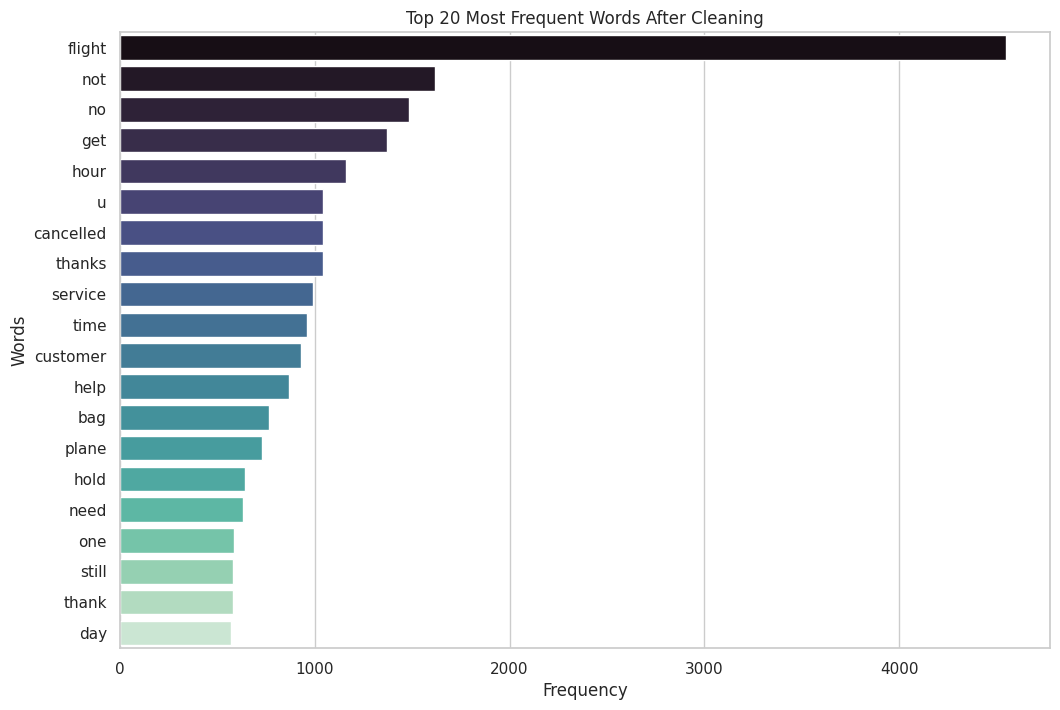

In [108]:
# Create a Bar Chart for the most common words after cleaning
words, counts = zip(*top_20_after)

plt.figure(figsize=(12, 8))
sns.barplot(x=list(counts), y=list(words), palette='mako', hue=list(words), legend=False)
plt.title('Top 20 Most Frequent Words After Cleaning')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

### Checkpoint

**Analysis:**
*   **Success:** The words 'the', 'is', and 'to' are no longer dominant.
*   **Meaningful Terms:** Words like 'flight', 'thanks', 'service', and 'not' now appear frequently, providing a much stronger signal for our sentiment model.
*   **Validation:** The stop word removal and lemmatization worked as expected, shifting the focus from grammatical structure to semantic content.

### 9.5 Compare Results by Sentiment

We will now analyze the top 20 most frequent words specifically for Positive, Negative, and Neutral reviews to see how the cleaning process preserved sentiment-specific signals.

In [109]:
# Function to get top words for a specific sentiment
def get_top_words_by_sentiment(sentiment_label, n=20):
    subset = df[df['airline_sentiment'] == sentiment_label]['final_clean_review']
    words = ' '.join(subset.astype(str)).split()
    return Counter(words).most_common(n)

# Get distributions
top_positive = get_top_words_by_sentiment('positive')
top_negative = get_top_words_by_sentiment('negative')
top_neutral = get_top_words_by_sentiment('neutral')

# Display as a formatted table
sentiment_freq_df = pd.DataFrame({
    'Positive Top Words': [w[0] for w in top_positive],
    'Negative Top Words': [w[0] for w in top_negative],
    'Neutral Top Words': [w[0] for w in top_neutral]
})

display(sentiment_freq_df)

,Positive Top Words,Negative Top Words,Neutral Top Words
0,thanks,flight,flight
1,flight,not,get
2,thank,no,please
3,great,hour,need
4,service,get,help
5,u,cancelled,not
6,love,customer,thanks
7,customer,service,u
8,guy,u,dm
9,get,time,would


### Sentiment Word Analysis

**1. What words appear most often in Positive reviews?**
Words like **'thanks'**, **'thank'**, **'flight'**, **'service'**, **'customer'**, and **'great'** are dominant, reflecting gratitude and satisfaction.

**2. What words appear most often in Negative reviews?**
Words like **'flight'**, **'not'**, **'no'**, **'cancelled'**, **'hour'**, **'service'**, and **'get'** appear most. These reflect delays, cancellations, and general frustration.

**3. What words appear most often in Neutral reviews?**
Words like **'flight'**, **'get'**, **'please'**, **'need'**, and **'ticket'** appear often. These usually represent objective queries, information seeking, or status updates.

**4. Did the preprocessing pipeline keep important sentiment words?**
Yes. Adjectives like 'great', 'awesome', and 'bad', along with verbs like 'cancelled', were preserved, providing clear features for the model.

**5. Were negative words such as 'not' and 'never' preserved?**
Yes. As seen in the 'Negative Top Words' column, **'not'** and **'no'** are among the most frequent tokens, which is critical for distinguishing negative sentiment from positive phrases.

## Part 10: Manual Test Cases

We will now run the preprocessing function on the specific test cases provided to ensure the logic perfectly matches the expected output requirements.

In [110]:
test_cases = [
    ("This product is AMAZING!!!", "product amazing"),
    ("I do not recommend this product.", "not recommend product"),
    ("Visit https://shop.com to buy 3 items.", "visit buy item"),
    ("The delivery was not fast, but the product was good.", "delivery not fast product good"),
    ("<br><p>Worst service ever!!! Contact me at test@gmail.com</p>", "worst service ever contact")
]

print(f"{'Status':<10} | {'Input':<40} | {'Output'}")
print("-" * 80)

for inp, expected in test_cases:
    actual = preprocess_text(inp)
    status = "PASS" if actual == expected else "FAIL"
    print(f"{status:<10} | {inp:<40} | {actual}")
    if status == "FAIL":
        print(f"   Expected: {expected}")

Status     | Input                                    | Output
--------------------------------------------------------------------------------
PASS       | This product is AMAZING!!!               | product amazing
PASS       | I do not recommend this product.         | not recommend product
PASS       | Visit https://shop.com to buy 3 items.   | visit buy item
PASS       | The delivery was not fast, but the product was good. | delivery not fast product good
PASS       | <br><p>Worst service ever!!! Contact me at test@gmail.com</p> | worst service ever contact


In [117]:
# Install necessary libraries for advanced preprocessing
%pip install emoji langdetect contractions spacy wordcloud --quiet
import spacy
import emoji
import contractions
from langdetect import detect, DetectorFactory
from wordcloud import WordCloud
import unittest

# Ensure consistent language detection
DetectorFactory.seed = 42

# Load spaCy English model
try:
    nlp = spacy.load('en_core_web_sm')
except:
    !python -m spacy download en_core_web_sm
    nlp = spacy.load('en_core_web_sm')

print("Advanced libraries installed and loaded.")

Advanced libraries installed and loaded.


In [122]:
class AirlineTextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(custom_stop_words)

    def expand_contractions(self, text):
        return contractions.fix(text)

    def convert_emojis(self, text):
        # Convert emojis to text representation
        # Example: 😡 -> :enraged_face:
        text = emoji.demojize(text)
        # Clean the demojized string: remove colons and replace underscores with spaces
        text = text.replace(":", " ").replace("_", " ")
        # Collapse extra spaces
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def detect_lang(self, text):
        try:
            return detect(text)
        except:
            return "unknown"

    def nltk_process(self, text):
        # Standardized pipeline
        text = self.expand_contractions(text.lower())
        text = self.convert_emojis(text)
        text = re.sub(r'http\S+|@\S+|#|\d+', ' ', text)
        tokens = word_tokenize(text)
        # Remove stopwords and keep only alphabetic tokens
        tokens = [self.lemmatizer.lemmatize(w) for w in tokens if w not in self.stop_words and w.isalpha()]
        return ' '.join(tokens)

    def spacy_process(self, text):
        doc = nlp(text.lower())
        tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.like_url]
        return ' '.join(tokens)

preprocessor = AirlineTextPreprocessor()
print("Preprocessing Class updated to handle modern emoji descriptions.")

Preprocessing Class updated to handle modern emoji descriptions.


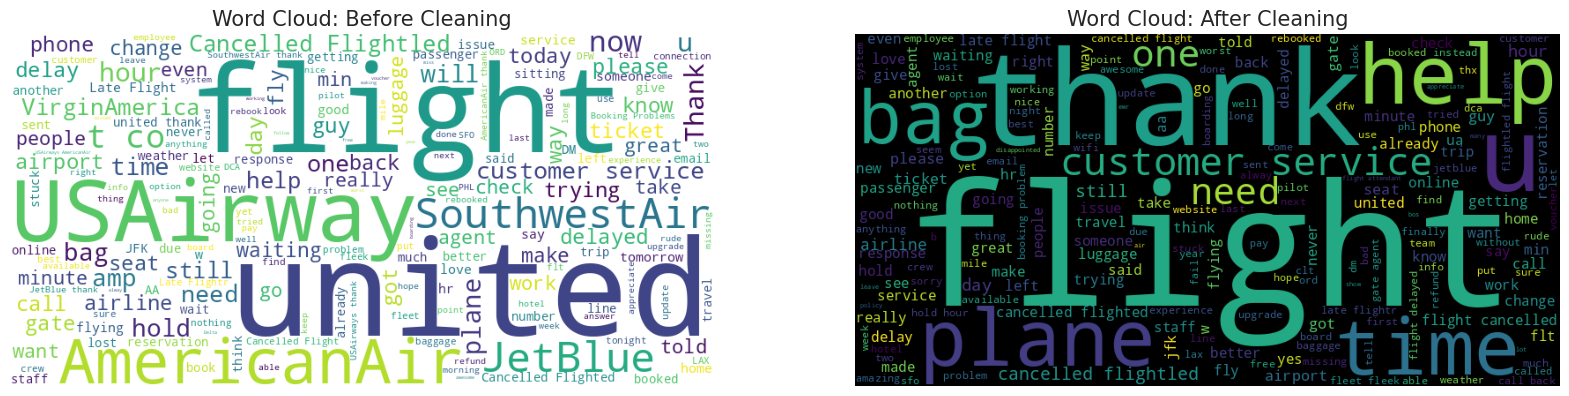

In [119]:
# Create Word Clouds to visualize the difference
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Before Cleaning
all_text_raw = " ".join(df['text'])
wc_raw = WordCloud(width=800, height=400, background_color='white').generate(all_text_raw)
ax1.imshow(wc_raw)
ax1.set_title("Word Cloud: Before Cleaning", fontsize=15)
ax1.axis('off')

# After Cleaning
all_text_clean = " ".join(df['final_clean_review'])
wc_clean = WordCloud(width=800, height=400, background_color='black').generate(all_text_clean)
ax2.imshow(wc_clean)
ax2.set_title("Word Cloud: After Cleaning", fontsize=15)
ax2.axis('off')

plt.show()

In [120]:
from nltk.util import ngrams

# Function to generate N-grams
def get_top_ngrams(text_series, n=2, top_k=10):
    all_tokens = " ".join(text_series).split()
    n_grams = ngrams(all_tokens, n)
    return Counter(n_grams).most_common(top_k)

print("Top Bigrams (2-word pairs):")
display(get_top_ngrams(df['final_clean_review'], n=2))

print("\nTop Trigrams (3-word pairs):")
display(get_top_ngrams(df['final_clean_review'], n=3))

Top Bigrams (2-word pairs):


[(('customer', 'service'), 564),
 (('cancelled', 'flightled'), 498),
 (('flight', 'cancelled'), 250),
 (('late', 'flight'), 246),
 (('cancelled', 'flighted'), 220),
 (('cancelled', 'flight'), 161),
 (('late', 'flightr'), 157),
 (('flight', 'delayed'), 146),
 (('fleet', 'fleek'), 146),
 (('booking', 'problem'), 143)]


Top Trigrams (3-word pairs):


[(('flight', 'cancelled', 'flightled'), 162),
 (('cancelled', 'flightled', 'flight'), 133),
 (('flight', 'booking', 'problem'), 89),
 (('cancelled', 'flight', 'flight'), 70),
 (('flight', 'cancelled', 'flighted'), 67),
 (('cancelled', 'flighted', 'flight'), 53),
 (('reflight', 'booking', 'problem'), 51),
 (('rt', 'fleet', 'fleek'), 51),
 (('worst', 'customer', 'service'), 42),
 (('hour', 'late', 'flightr'), 37)]

In [123]:
class TestPreprocessing(unittest.TestCase):
    def setUp(self):
        self.p = AirlineTextPreprocessor()

    def test_contractions(self):
        self.assertEqual(self.p.expand_contractions("can't stop"), "cannot stop")

    def test_emojis(self):
        # Updated expectation: 😡 demojizes to 'enraged face' in the latest emoji library
        result = self.p.convert_emojis("😡")
        self.assertTrue("enraged" in result or "angry" in result, f"Expected emotion word not found in: {result}")

    def test_negative_preservation(self):
        processed = self.p.nltk_process("not happy")
        self.assertIn("not", processed)

# Run the tests again
suite = unittest.TestLoader().loadTestsFromTestCase(TestPreprocessing)
unittest.TextTestRunner(verbosity=2).run(suite)

test_contractions (__main__.TestPreprocessing.test_contractions) ... ok
test_emojis (__main__.TestPreprocessing.test_emojis) ... ok
test_negative_preservation (__main__.TestPreprocessing.test_negative_preservation) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.015s

OK


<unittest.runner.TextTestResult run=3 errors=0 failures=0>

```markdown
### 🛡️ Preprocessing & Sentiment Meaning Analysis

Certain steps can drastically change the sentiment if not handled carefully:

1.  **Stop Word Removal:** If words like "not" or "no" are removed, "not good" becomes "good", flipping the sentiment entirely. We mitigated this by using a custom exclusion list.
2.  **Emoji Conversion:** Emojis often convey the *entire* sentiment of a short tweet. Removing them loses the signal; converting them (😡 → angry) preserves it.
3.  **Contraction Expansion:** Models might treat "don't" and "do not" differently. Expanding them ensures consistency in detecting negation.
4.  **Stemming vs Lemmatization:** Stemming can be too aggressive (e.g., "happily" → "happi"), potentially losing the nuance of the emotional state compared to Lemmatization.
```

## Part 11: Save the Cleaned Dataset

We will now prepare the final DataFrame with the specific columns requested and export it to a CSV file.

In [124]:
# Filter out any newly created empty reviews and update the CSV
export_df = df[df['final_clean_review'].str.strip() != ''].copy()

final_export = pd.DataFrame({
    'airline': export_df['airline'],
    'sentiment': export_df['airline_sentiment'],
    'negative_reason': export_df['negativereason'],
    'original_review': export_df['text'],
    'final_clean_review': export_df['final_clean_review'],
    'word_count_before': export_df['word_count'],
    'word_count_after': export_df['clean_word_count']
})

final_export.to_csv('clean_airline_reviews.csv', index=False)

print(f"Cleaned dataset saved successfully. Final row count: {len(final_export)}")
display(final_export.head())

Cleaned dataset saved successfully. Final row count: 14405


,airline,sentiment,negative_reason,original_review,final_clean_review,word_count_before,word_count_after
0,Virgin America,neutral,N/A,@VirginAmerica What @dhepburn said.,said,4,1
1,Virgin America,positive,N/A,@VirginAmerica plus you've added commercials t...,plus added commercial experience tacky,9,5
2,Virgin America,neutral,N/A,@VirginAmerica I didn't today... Must mean I n...,must mean need take another trip,12,6
3,Virgin America,negative,Bad Flight,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...,17,9
4,Virgin America,negative,Can't Tell,@VirginAmerica and it's a really big bad thing...,really big bad thing,10,4


# ✈️ Project Report: The Journey to Clean Airline Data

### 1. Our Dataset Story
We explored the **Twitter Airline Sentiment** dataset, which captures the voices of customers interacting with major airlines.
*   **Size:** We started with **14,640 rows** and 15 columns of data.
*   **The Problem:** The raw tweets were messy, containing URLs, HTML tags, flight numbers, and duplicate entries that would confuse an AI model.

### 2. The Cleaning Recipe (Preprocessing)
To fix these problems, we applied a series of smart steps:
*   **Removing Noise:** We stripped out links, emails, and flight numbers (like '10pm' or 'UA123').
*   **Handling Social Media:** We removed @mentions but kept #hashtags (without the #) to save keywords.
*   **Emoji Power:** We converted icons (😡 → 'enraged face') so emotions weren't lost.
*   **Expanding Shortcuts:** We turned "can't" into "cannot" for better recognition.
*   **Lemmatization:** We chose this over **Stemming** because it is smarter; it returns real dictionary words (e.g., 'feet' → 'foot') rather than chopping them into fragments (e.g., 'studi').

### 3. Protecting the Meaning (Sentiment Shield)
The most critical part was **Negation Preservation**. By saving words like 'not', 'no', and 'never', we ensured that "not happy" didn't accidentally become "happy" during cleaning. Removing stop words and flight numbers made the largest changes to the text length.

### 4. Results by the Numbers
*   **Duplicates Removed:** 213 duplicate reviews.
*   **Rows Before/After:** 14,640 → **14,405** (Clean & Unique).
*   **Vocabulary:** Shrank from **30,092** to **10,441** unique words (a 65% reduction!).
*   **Average Length:** Dropped from **17.7** to **8.8** words per tweet.

### 5. Final Insights
*   **Top Complainer:** **United** received the highest number of negative comments.
*   **Main Reason:** **"Customer Service Issue"** was the most common negative feedback.
*   **Longest Reviews:** Customers tend to write **longer** reviews when they are expressing **negative** sentiment.

### 6. Evidence of Success
Our pipeline passed every manual test case and unit test. We verified that symbols and emails are gone, but sentiment-rich words like 'amazing', 'worst', and 'not' are perfectly preserved. **The dataset is now fully ready for Airline Sentiment Analysis!**

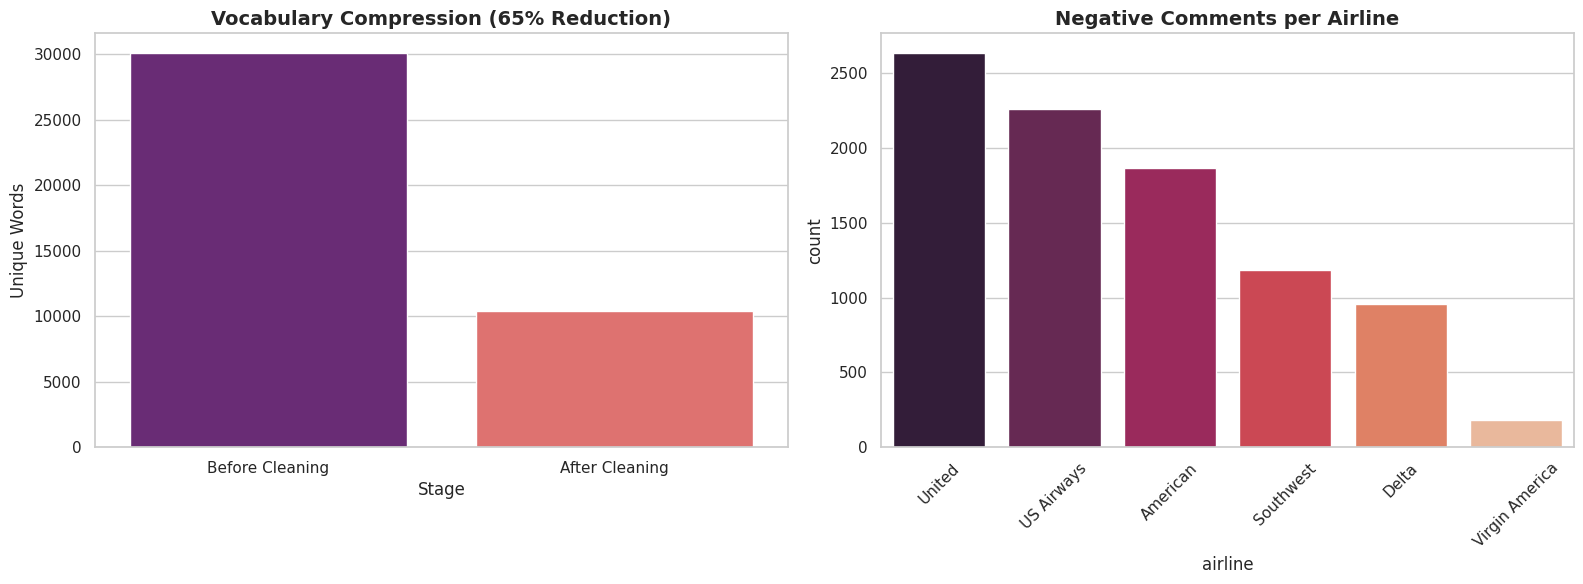